In [3]:
import pandas as pd 
#charger le dataset 
df =pd.read_csv("car_dataset.csv")

In [7]:
df.shape

(205, 26)

In [8]:
df.describe()


,ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [4]:
df.head()

,ID,symboling,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


<Axes: xlabel='enginesize', ylabel='price'>

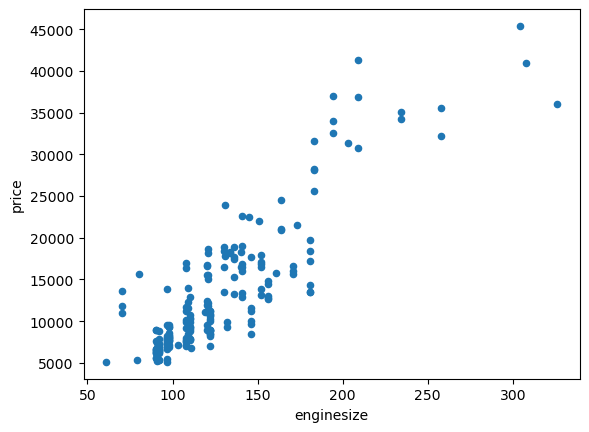

In [14]:
df.plot(x='enginesize' , y='price', kind='scatter')

Intercept (b0): -8005.445531145211
Coefficient (b1): 167.6984163931722
Mean Squared Error: 14980261.40555132


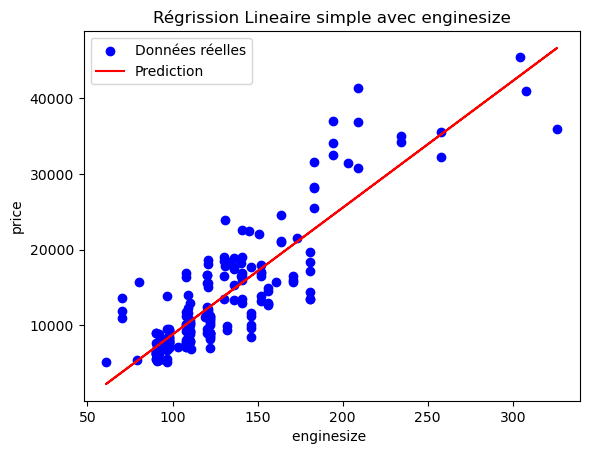

In [4]:
#importation des biblio necessaires

from sklearn.linear_model import LinearRegression , LogisticRegression
from sklearn.metrics import mean_squared_error 
from sklearn.preprocessing import PolynomialFeatures 
import matplotlib.pyplot as plt 
import numpy as np

#Regression simple avec scikit-learn
#definer x and y variabble explicative et cible
x= df[['enginesize']]
y= df['price']


#cree et entrainer le model
model = LinearRegression() 
model.fit(x,y) 
#predire
y_pred=model.predict(x)
#afficher les coefficient
print("Intercept (b0):" , model.intercept_)
print("Coefficient (b1):", model.coef_[0])
#evaluation
mse =mean_squared_error(y,y_pred)

print("Mean Squared Error:",mse)


#visualisation la correlation globale
plt.scatter(x , y, color= 'blue' , label ='Données réelles' )
plt.plot(x , y_pred , color='red' , label='Prediction')
plt.xlabel("enginesize " )
plt.ylabel("price")
plt.title("Régrission Lineaire simple avec enginesize")
plt.legend()
plt.show() 


---- Régression multiple ----
Intercept (b0): -46218.306921317126
Coefficients (b1,b2,b3): [ 108.98176431  -64.81956894  546.50705722    2.79262933   83.10704923
   52.37931057 -109.55171868  117.74128892]
MSE: 11336484.082952462


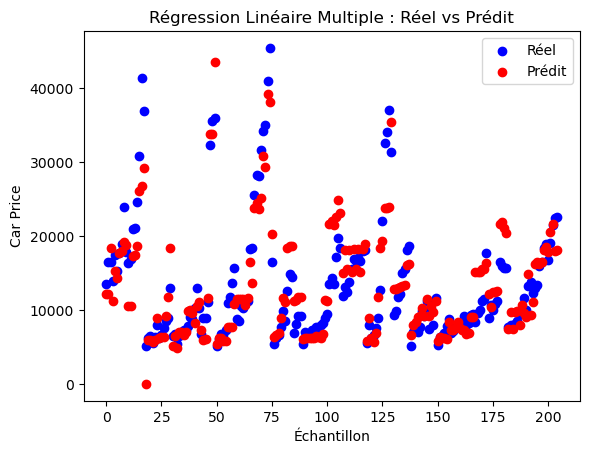

In [16]:
#regression multiple avec sckit-learn
#difinir les variables
#x_multiple : variable explicative (plusieurs features )
x_multiple = df[['wheelbase','carlength','carwidth','curbweight','enginesize','horsepower','citympg','highwaympg']]
#y_multiple: variable cible
y_multiple = df['price']



#cree et entrainer le model
#LiniarRegression applique la formule :
#y=b0 +b1x1+b2x2+ ...+ bnxn
model_multiple = LinearRegression() 
#le model apprendre la relation entre x et y
model_multiple.fit(x_multiple,y_multiple )

#predire
y_pred_m=model_multiple.predict(x_multiple)

#afficher
print("\n---- Régression multiple ----")
#b0 ; constante
print("Intercept (b0):", model_multiple.intercept_)
#coefficient associes a chaque variable
print("Coefficients (b1,b2,b3):", model_multiple.coef_)
#evaluer le model
#MSE mesure l ereur moyaane entre reeel et predit
print("MSE:", mean_squared_error(y_multiple, y_pred_m))


#visualisation l erreur indivuelle 
plt.scatter(range(len(y_multiple)),y_multiple, color='blue', label='Réel')
plt.scatter(range(len(y_pred_m)), y_pred_m, color='red', label='Prédit')
plt.xlabel("Échantillon")
plt.ylabel("Car Price")
plt.title("Régression Linéaire Multiple : Réel vs Prédit")
plt.legend()
plt.show()


Shape original x : (205, 1)
Shape polynomial x: (205, 3)

----- Régression Polynomiale -----
Intercept (b0): -8633.015921744878
Coefficients: [ 0.00000000e+00  1.76231991e+02 -2.55397620e-02]
MSE: 14973637.600078518


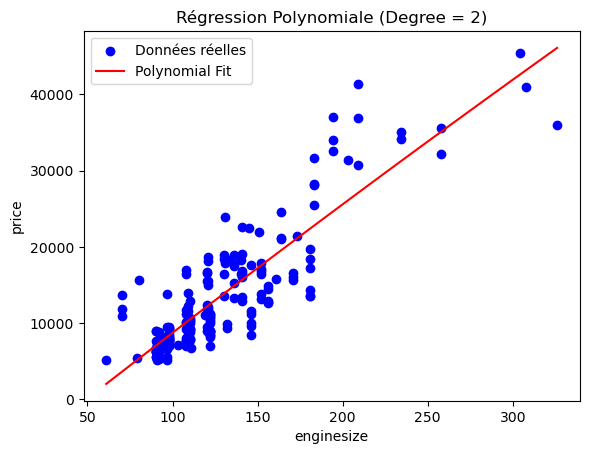

In [19]:
#Regression Polynomial avec scikit-learn 
#Transformer en polynomial features
#degree =2 -> 1,x,x²
poly = PolynomialFeatures(degree =2) #ici degre =2 
#transformation automatique 
x_poly =poly.fit_transform(x) #sklearn cree auto 1,x,x²

print("Shape original x :", x.shape)
print ("Shape polynomial x:",x_poly.shape)
  
#Creation du model
model=LinearRegression()
#Entrainer le modele 
model.fit(x_poly,y)
#prediction
y_pred_p = model.predict(x_poly)
#evaluation 
print("\n----- Régression Polynomiale -----")
# constante b0
print("Intercept (b0):", model.intercept_)
#coefficients b1,b2 ...
print("Coefficients:", model.coef_)


mse=mean_squared_error(y,y_pred_p)
print("MSE:",mse)

#visualisation
#creer une plage continue de valeurs enginesize
X_range = pd.DataFrame(
    np.linspace(x.min().values[0], x.max().values[0], 100),
    columns=['enginesize']
)
#transformer en polynomial
x_range_poly =poly.transform(X_range)
#prediciton
y_range_pred =model.predict(x_range_poly)
#afficher
plt.scatter(x,y,color='blue' ,label='Données réelles')
plt.plot(X_range,y_range_pred , color ='red' , label='Polynomial Fit')

plt.xlabel("enginesize")
plt.ylabel("price")
plt.title("Régression Polynomiale (Degree = 2)")
plt.legend()
plt.show()

In [21]:
#Regression linear simple from scratch
class SimpleLinearRegression:

    def __init__(self, learning_rate=0.01, iterations=2000):
        #taux d apprentissge et nombre de repition 
        self.lr = learning_rate
        self.iterations = iterations
        #prametre du model 
        self.weight = 0
        self.bias = 0
        #historique de l erreur 
        self.losses =[]

    #Mean Squared Error    
    def mse(self ,y, y_pred) :
        return np.mean((y-y_pred)**2)

    # fonction d'entraînement
    def fit(self, X, y):

        n = len(X)
        #prediction

        for i in range(self.iterations):

            # Prediction
            y_pred = self.weight * X + self.bias

            loss =self.mse(y,y_pred)
            self.losses.append(loss)

            # Calcul des gradients
            dw = (-2/n) * np.sum(X * (y - y_pred))
            db = (-2/n) * np.sum(y - y_pred)

            # Update paramètres
            self.weight -= self.lr * dw
            self.bias -= self.lr * db

    # fonction prédiction
    
    def predict(self, X):
        return self.weight * X + self.bias


Weight : 110.73834940926538
Bias : -2.3105506027604097
Final MSE: 21178888.972006448


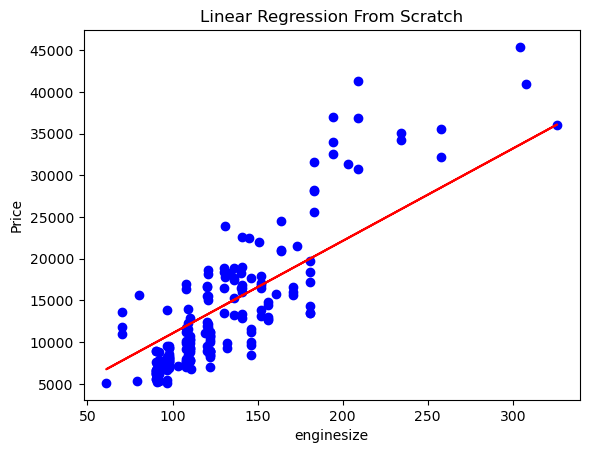

In [26]:
#Preparer les donnees
#recuperer les valeur numpy
X = df['enginesize'].values
y = df['price'].values

#Cree le modele 
model = SimpleLinearRegression(learning_rate=0.000001, iterations=2000)
#Entrainer le modele
model.fit(X, y)
#Prediction
y_pred = model.predict(X)
#Resultat
print("Weight :", model.weight)
print("Bias :", model.bias)

final_mse = np.mean((y - y_pred)**2)
print("Final MSE:", final_mse)
#Visualistion 

plt.scatter(X, y, color="blue")
plt.plot(X, y_pred, color="red")
plt.xlabel("enginesize")
plt.ylabel("Price")
plt.title("Linear Regression From Scratch")
plt.show()

In [35]:
class MultipleLinearRegression :
    def __init__(self, learning_rate =0.0000001,iterations= 3000) :
        self.lr =learning_rate 
        self.iterations =iterations 
        self.weights =None
        self.bias=None
        self.losses=[] 
    def mse(self,y_multiple,y_pred ) :
        return np.mean((y_multiple-y_pred)**2)
        
    def fit(self,X_multiple,y_multiple) :
        #n_samples :nombre de ligne , n_features: nombre de colonnes
        n_samples, n_features =X_multiple.shape 
        #initialisation des poids a zero
        self.weights =np.zeros(n_features) 
        self.bias=0
        #boucle d apprentisge
        for i in range(self.iterations) :
            #calcule de la prediction
            y_pred =np.dot(X_multiple,self.weights)+self.bias 
            #Enrgstrement de l erreur actuelle 
            loss=self.mse(y_multiple,y_pred)
            self.losses.append(loss)
            #Calcul des gradiant

            dw=(-2/n_samples) *np.dot(X_multiple.T,(y_multiple-y_pred))
            db= (-2/n_samples ) *np.sum(y_multiple -y_pred) 
            #Mise a jour des parametre
            self.weights -=self.lr *dw 
            self.bias -= self.lr *db

    def predict (self , X_multiple) :
        #appication du model entraine sur de nouvelle donnes
        return np.dot(X_multiple,self.weights) + self.bias
            
        


Weights : [-23.07937131 -36.94093431 -16.32401778   6.3060363   36.83691466
  33.50638004 -15.37470692 -17.37886318]
Bias : -0.29529397661401
Final MSE: 15612639.992973177


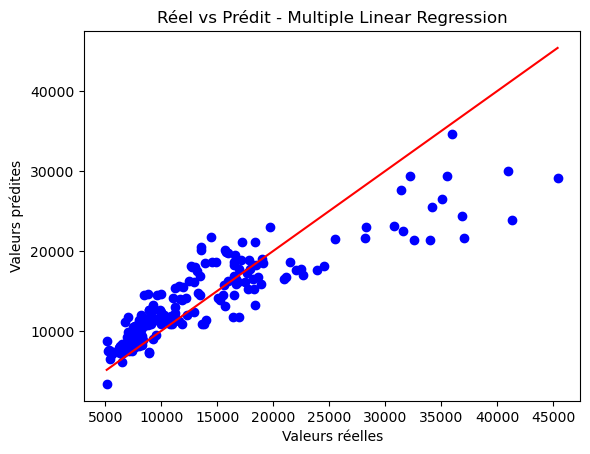

In [36]:
#les variable x et y 
#variable explicative 
X_multiple = df[['wheelbase','carlength','carwidth','curbweight','enginesize','horsepower','citympg','highwaympg']]
#variable cible
y_multiple = df['price']


#creation du modéle
model_multi = MultipleLinearRegression() 
#entrainement du model 
#le model apprend :
#les poid (w1,w2..) 
# bias (b)
model_multi.fit(X_multiple, y_multiple )
#Predictions
y_pred_multi =model_multi.predict(X_multiple)
#affichage des paramtres
print("Weights :", model_multi.weights)
print("Bias :", model_multi.bias)
#evaluation du model
mse_final = np.mean((y_multiple - y_pred_multi)**2)
print("Final MSE:", mse_final)
#visualisation

plt.scatter(y_multiple, y_pred_multi, color='blue')

plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Réel vs Prédit - Multiple Linear Regression")

plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         color='red')  # ligne parfaite

plt.show()

In [51]:
class PolynomialRegression:

    def __init__(self, learning_rate=0.000000001, iterations=4000):
        #taux d apprentissage et nombre d itersssion 
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        #stockage de l erreur
        self.losses = []
    #mean squared Error
    def mse(self, y, y_pred):
        return np.mean((y - y_pred)**2)
    #entrainement du model
    def fit(self, X, y):
        # n_samples → nombre de lignes
        # n_features → nombre de colonnes
        n_samples, n_features = X.shape
        #initialistion a zero
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        #Gradient Descent
        for _ in range(self.iterations):
            #prediction
            y_pred = np.dot(X, self.weights) + self.bias
            #calculer les erreur
            loss = self.mse(y, y_pred)
            self.losses.append(loss)
            #calcul des gradiant
            dw = (-2/n_samples) * np.dot(X.T, (y - y_pred))
            db = (-2/n_samples) * np.sum(y - y_pred)
            #mise ajour des paramtree
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
    #prediction
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

MSE: 26232133.64030985


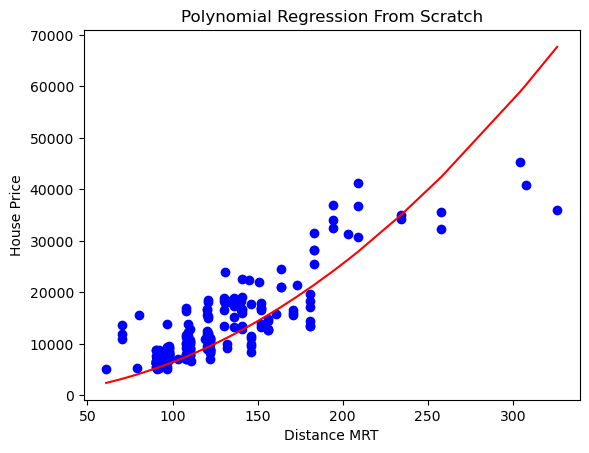

In [52]:
#Preparer les donnes 
X = df['enginesize'].values
y = df['price'].values
#degreee du polynome 
degree = 2
#creation des varibaes polynomiales
#transfrome x ->[x,x²] 
X_poly = np.column_stack([X**i for i in range(1, degree+1)])

#cretion du modele 

model_poly = PolynomialRegression()
#entrainement 
model_poly.fit(X_poly, y)
#prediction
y_pred_poly = model_poly.predict(X_poly)
#evaluation 
mse = np.mean((y - y_pred_poly)**2)

print("MSE:", mse)
#visualisation


sorted_index = np.argsort(X)

plt.scatter(X, y, color='blue')
plt.plot(X[sorted_index],
         y_pred_poly[sorted_index],
         color='red')

plt.xlabel("Distance MRT")
plt.ylabel("House Price")
plt.title("Polynomial Regression From Scratch")
plt.show()



---------Parametres du models ---------
Intercept (b0): [-9.67705396]
Coefficient (b1): [[0.08126797]]


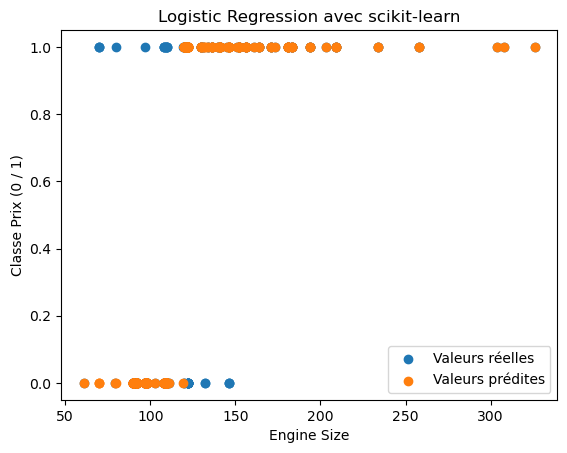

In [5]:
#regrssion logistique biblio version 
#transformer la variable price en classes 
#1->voiture chere 
#0-> voiture pas chere 

df['price_class'] = (df['price'] > df['price'].median()).astype(int)

#variable explicative (feature)
X = df[['enginesize']]

#varibalee cible
y=df['price_class']

#creation du modele logistic regression 
model = LogisticRegression()

#le model apprend les paramtres 
model.fit(X,y)

#Prediction 
y_pred = model.predict(X)

#affichage ds paramatres 
print("\n---------Parametres du models ---------")
print("Intercept (b0):", model.intercept_)
print("Coefficient (b1):", model.coef_)
#visualisation 

plt.scatter(X, y, label="Valeurs réelles")
plt.scatter(X, y_pred, label="Valeurs prédites")

plt.xlabel("Engine Size")
plt.ylabel("Classe Prix (0 / 1)")
plt.title("Logistic Regression avec scikit-learn")
plt.legend()
plt.show()



In [13]:
class LogisticRegression :
    def __init__(self, learning_rate =0.001, iterations =5000 ) :
        #taux d apprentissage 
        self.lr = learning_rate
        #nombre d itrations du gradiant descent 
        self.iterations  = iterations  
        #parametres du modele 
        self.wieght = None 
        self.bias =0

    #fonction sigmoid 
    #transforme valeur reelle -> entre 0 et 1
    def sigmoid(self,z) :
        return 1/(1+np.exp(-z))

    #entrainemeent 
    def fit (self, X,y) :
        n_samples , n_features =X.shape 

        #initialisations des poids 
        self.weights = np.zeros(n_features)
        self.bias =0 

        #gradient descent
        for  _ in range (self.iterations):
            #combinaison lineare 
            linear_model = np.dot(X,self.weights ) +self.bias
            #active=ation sigmoid 
            y_pred =self.sigmoid(linear_model)
            #gradients
            dw =(1/ n_samples)*np.dot(X.T, (y_pred -y))
            db =(1/n_samples)*np.sum(y_pred -y)

            #mise a jour 
            self.weights -=self.lr*dw
            self.bias-=self.lr*db
    def predict(self ,X ):
        #calcul du model lineaire
        #z=wX +b
        linear_model = np.dot(X, self.weights) +self.bias 
        #application de la fonction sigmoide 
        #transforme z en proba entre 0 et 1
        y_pred =self.sigmoid(linear_model)
        #conversion en classes (0 ou1)
        #si proba >0.5 ->classe 1
        #sinon -> classe 0

        y_class =[1 if i > 0.5 else 0 for i in y_pred]

        return np.array(y_class)





        

        


--------- Paramètres du modèle ---------
Weights (b1): [-0.0008326]
Bias (b0): -0.4935695965672512


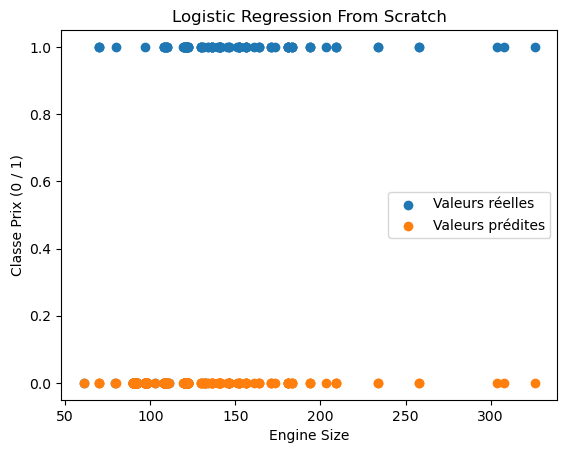

In [14]:
# X = feature
X = df[['enginesize']].values

# créer classes 0 / 1
y = (df['price'] > df['price'].median()).astype(int).values

# créer modèle
model = LogisticRegression()

# entrainement
model.fit(X, y)

# prédictions
y_pred = model.predict(X)

print("\n--------- Paramètres du modèle ---------")
print("Weights (b1):", model.weights)
print("Bias (b0):", model.bias)

plt.scatter(X, y, label="Valeurs réelles")
plt.scatter(X, y_pred, label="Valeurs prédites")

plt.xlabel("Engine Size")
plt.ylabel("Classe Prix (0 / 1)")
plt.title("Logistic Regression From Scratch")
plt.legend()
plt.show()